In [1]:
# eda06: imports and config (dataclasses needed for unpickling eda02)
import math
import numpy as np
import torch
import pickle
import tqdm
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import enum
from dataclasses import dataclass

class MoonInfoOrigin(enum.Enum):
    DIRECT = 0
    INTERPOLATED = 1

@dataclass
class ImageInfo:
    path: Path
    width: int
    height: int
    avg_brightness: float
    timestamp: float
    exposure_time: float
    moon: tuple[float, float, float] = None
    moon_info_origin: MoonInfoOrigin = None
    moon_pos_std_px: float = None

PKL_DIR = "/home/slavik/tmp"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Methods: register within exposure groups -> averaged images per exposure
def load_grayscale(ii, device):
    with Image.open(ii.path) as img:
        arr = np.array(img).astype(np.float32) / 255.0
    if arr.ndim == 3:
        arr = arr.mean(axis=2)
    return torch.from_numpy(arr).to(device=device, dtype=torch.float32)

def apply_transform_single(img, shift_i, shift_j, angle_deg, device):
    H, W = img.shape
    ci, cj = H / 2.0, W / 2.0
    if not isinstance(angle_deg, torch.Tensor):
        angle_deg = torch.tensor(angle_deg, device=device, dtype=torch.float32)
    if not isinstance(shift_i, torch.Tensor):
        shift_i = torch.tensor(shift_i, device=device, dtype=torch.float32)
    if not isinstance(shift_j, torch.Tensor):
        shift_j = torch.tensor(shift_j, device=device, dtype=torch.float32)
    angle_rad = torch.deg2rad(-angle_deg)
    cos_a = torch.cos(angle_rad)
    sin_a = torch.sin(angle_rad)
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    di = ii - ci - shift_i
    dj = jj - cj - shift_j
    i_src = di * cos_a + dj * sin_a + ci
    j_src = -di * sin_a + dj * cos_a + cj
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

def compute_weighted_average(group, abs_xy, abs_angle_t, device, epsilon=1e-6):
    n = len(group)
    sum_img = None
    sum_mask = None
    for j in range(n):
        img_j = load_grayscale(group[j], device)
        mj_i, mj_j, r_j = group[j].moon[0], group[j].moon[1], group[j].moon[2]
        H, W = img_j.shape
        ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
        jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
        dist = torch.sqrt((ii - mj_i) ** 2 + (jj - mj_j) ** 2)
        img_j = img_j.clone()
        mask_j = (dist > r_j + 2.0).to(torch.float32)
        del ii, jj, dist
        x_j = abs_xy[j, 0]
        y_j = abs_xy[j, 1]
        theta_j_deg = -torch.rad2deg(abs_angle_t[j])
        w_img = apply_transform_single(img_j, x_j, y_j, theta_j_deg, device)
        w_mask = apply_transform_single(mask_j, x_j, y_j, theta_j_deg, device)
        if sum_img is None:
            sum_img = w_img * w_mask
            sum_mask = w_mask.clone()
        else:
            sum_img = sum_img + w_img * w_mask
            sum_mask = sum_mask + w_mask
        del img_j, mask_j, w_img, w_mask
    avg_img = sum_img / (sum_mask + epsilon)
    avg_mask = sum_mask / n
    return avg_img, avg_mask

def build_averaged_images(exposure_groups, opt_results, exposure_times_sorted, device):
    """opt_results[exp]['abs_xy'], ['abs_angle_t'] must be tensors on device (e.g. requires_grad=True for diff)."""
    avg_images, avg_masks = {}, {}
    for exp in tqdm.tqdm(exposure_times_sorted, desc="Averaged images"):
        group = exposure_groups[exp]
        if exp not in opt_results or len(group) < 2:
            continue
        abs_xy = opt_results[exp]["abs_xy"]
        abs_angle_t = opt_results[exp]["abs_angle_t"]
        if isinstance(abs_xy, np.ndarray):
            abs_xy = torch.from_numpy(abs_xy).to(device=device, dtype=torch.float32)
        if isinstance(abs_angle_t, np.ndarray):
            abs_angle_t = torch.from_numpy(abs_angle_t).to(device=device, dtype=torch.float32)
        avg_images[exp], avg_masks[exp] = compute_weighted_average(group, abs_xy, abs_angle_t, device)
        if device.type == "cuda":
            torch.cuda.empty_cache()
    return avg_images, avg_masks

In [3]:
# Methods: register across exposure groups -> chain of transforms per exposure
def ref_to_source_grid(H, W, chain_tuples, device):
    """chain_tuples: list of (shift_i, shift_j, rotation_deg); each can be tensor (for grad) or float."""
    ci, cj = H / 2.0, W / 2.0
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    i_cur = ii.clone()
    j_cur = jj.clone()
    for (shift_i, shift_j, rotation_deg) in chain_tuples:
        if not isinstance(rotation_deg, torch.Tensor):
            rotation_deg = torch.tensor(rotation_deg, device=device, dtype=torch.float32)
        if not isinstance(shift_i, torch.Tensor):
            shift_i = torch.tensor(shift_i, device=device, dtype=torch.float32)
        if not isinstance(shift_j, torch.Tensor):
            shift_j = torch.tensor(shift_j, device=device, dtype=torch.float32)
        angle_rad = torch.deg2rad(-rotation_deg)
        cos_a = torch.cos(angle_rad)
        sin_a = torch.sin(angle_rad)
        di = i_cur - ci - shift_i
        dj = j_cur - cj - shift_j
        i_cur = di * cos_a + dj * sin_a + ci
        j_cur = -di * sin_a + dj * cos_a + cj
    return i_cur, j_cur

def grid_to_normalized_grid(i_src, j_src, H, W):
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    return torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)

def warp_to_ref(img, chain_tuples, H_ref, W_ref, device):
    i_src, j_src = ref_to_source_grid(H_ref, W_ref, chain_tuples, device)
    grid = grid_to_normalized_grid(i_src, j_src, img.shape[0], img.shape[1])
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

def scale_to_ref(exposure_times_sorted, gamma_by_pair, k):
    if k == 0:
        return 1.0
    scale = 1.0
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in gamma_by_pair:
            return None
        g = gamma_by_pair[(t0, t1)]
        scale *= (t0 / t1) ** (1.0 / g)
    return scale

def build_chain(exposure_times_sorted, cross_reg, available_exposures):
    """available_exposures: set of exposure times that have opt_results and >=2 frames."""
    t_ref = exposure_times_sorted[0]
    exposures_with_chain = [t_ref]
    chain_tuples_by_exp = {t_ref: []}
    for k in range(1, len(exposure_times_sorted)):
        t_k = exposure_times_sorted[k]
        if t_k not in available_exposures:
            continue
        chain = []
        valid = True
        for i in range(k):
            t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
            if (t0, t1) not in cross_reg:
                valid = False
                break
            chain.append(cross_reg[(t0, t1)])
        if not valid:
            continue
        chain_tuples_by_exp[t_k] = chain
        exposures_with_chain.append(t_k)
    return chain_tuples_by_exp, exposures_with_chain

In [4]:
# Methods: build composite (weighted merge in reference frame)
WEIGHT_SIGMA = 0.2

def weight_from_value(y):
    """y: tensor or ndarray; returns same type (differentiable if y is tensor)."""
    if isinstance(y, torch.Tensor):
        y = torch.clamp(y, 0.0, 1.0)
        return torch.exp(-((y - 0.5) / WEIGHT_SIGMA) ** 2)
    y = np.clip(y, 0.0, 1.0).astype(np.float64)
    return np.exp(-((y - 0.5) / WEIGHT_SIGMA) ** 2)

def build_composite_streaming(exposure_groups, opt_results, exposures_with_chain, chain_tuples_by_exp,
                        exposure_times_sorted, gamma_by_pair, H_ref, W_ref, device):
    """Build composite without storing all averaged images; one exposure at a time."""
    sum_val = torch.zeros((H_ref, W_ref), device=device, dtype=torch.float32)
    sum_weight = torch.zeros((H_ref, W_ref), device=device, dtype=torch.float32)
    valid_all = None
    mask_0 = None
    for t_k in tqdm.tqdm(exposures_with_chain, desc="Warp and merge"):
        abs_xy = torch.from_numpy(opt_results[t_k]["abs_xy"].astype(np.float32)).to(device=device)
        abs_angle_t = torch.from_numpy(opt_results[t_k]["abs_angle_t"].astype(np.float32)).to(device=device)
        img_k, mask_k = compute_weighted_average(exposure_groups[t_k], abs_xy, abs_angle_t, device)
        if mask_0 is None:
            mask_0 = (mask_k > 0.99).float()
        chain = chain_tuples_by_exp[t_k]
        k_idx = exposure_times_sorted.index(t_k)
        scale_k = scale_to_ref(exposure_times_sorted, gamma_by_pair, k_idx)
        if scale_k is None:
            continue
        orig = img_k
        orig_clip = torch.clamp(orig, 0.0, 1.0)
        value_scaled = torch.clamp(orig * scale_k, 0.0, 1.0)
        weight_img = weight_from_value(orig_clip)
        if k_idx > 0:
            weight_img = weight_img * (mask_k > 0.99).float()
        valid_t = torch.ones_like(img_k, device=device, dtype=torch.float32)
        warped_val = warp_to_ref(value_scaled, chain, H_ref, W_ref, device) * mask_0
        warped_w = warp_to_ref(weight_img, chain, H_ref, W_ref, device)
        warped_valid = warp_to_ref(valid_t, chain, H_ref, W_ref, device)
        use = warped_valid >= 0.5
        sum_val = sum_val + torch.where(use, warped_val * warped_w, torch.zeros_like(sum_val))
        sum_weight = sum_weight + torch.where(use, warped_w, torch.zeros_like(sum_weight))
        if valid_all is None:
            valid_all = warped_valid.detach().clone()
        else:
            valid_all = torch.minimum(valid_all, warped_valid.detach())
        del img_k, mask_k, orig, orig_clip, value_scaled, weight_img, valid_t, warped_val, warped_w, warped_valid, use
        if device.type == "cuda":
            torch.cuda.empty_cache()
    denom = torch.clamp(sum_weight, min=1e-20)
    composite = sum_val / denom
    return composite, valid_all

In [5]:
# Methods: crop composite, convert to display (using radial params), sharpen (all differentiable in torch)
def crop_composite(composite, valid_all, valid_thresh=0.9999, margin=16):
    """composite, valid_all: tensors; returns composite_crop tensor (grad flows through)."""
    if isinstance(valid_all, torch.Tensor):
        v = valid_all.detach().cpu().numpy()
    else:
        v = valid_all
    all_valid_mask = v >= valid_thresh
    rows = np.any(all_valid_mask, axis=1)
    cols = np.any(all_valid_mask, axis=0)
    r_lo, r_hi = np.where(rows)[0][[0, -1]]
    c_lo, c_hi = np.where(cols)[0][[0, -1]]
    r_lo, r_hi = r_lo + margin, r_hi - margin
    c_lo, c_hi = c_lo + margin, c_hi - margin
    if isinstance(composite, torch.Tensor):
        return composite[r_lo : r_hi + 1, c_lo : c_hi + 1]
    return composite[r_lo : r_hi + 1, c_lo : c_hi + 1].copy()

def composite_to_display(composite_crop, mean_at_list, p3_at, moon_mask, device):
    """All inputs can be numpy or tensor; mean_at_list, p3_at, moon_mask converted to device tensors (no grad)."""
    if isinstance(composite_crop, np.ndarray):
        composite_crop = torch.from_numpy(composite_crop).to(device=device, dtype=torch.float32)
    if isinstance(p3_at, np.ndarray):
        p3_at = torch.from_numpy(p3_at).to(device=device, dtype=torch.float32)
    if isinstance(moon_mask, np.ndarray):
        moon_mask = torch.from_numpy(moon_mask).to(device=device)
    mean_tensors = []
    for m in mean_at_list:
        if isinstance(m, np.ndarray):
            m = torch.from_numpy(m).to(device=device, dtype=torch.float32)
        mean_tensors.append(m)
    display_ts = []
    for mean_at in mean_tensors:
        valid = torch.isfinite(mean_at) & (mean_at > 0)
        out = torch.zeros_like(composite_crop, device=device, dtype=torch.float32)
        v = composite_crop[valid]
        m = mean_at[valid]
        m2 = torch.clamp(m / 2.0, min=1e-9)
        m1 = torch.clamp(m, min=1e-9)
        out[valid] = torch.where((v > m/2) & (v <= m), 0.4 * (v - m/2) / m2, torch.zeros_like(v))
        out[valid] = torch.where((v > m) & (v <= 2*m), 0.4 + 0.6 * (v - m) / m1, out[valid])
        out[valid] = torch.where(v > 2*m, torch.ones_like(v), out[valid])
        display_ts.append(out)
    display_t = torch.stack(display_ts, dim=0).mean(dim=0)
    span = torch.clamp(1.0 - p3_at, min=1e-9)
    display_t = torch.clamp((display_t - p3_at) / span, 0.0, 1.0)
    display_t = display_t.masked_fill(moon_mask, 0.0)
    return display_t

def _gaussian_kernel_2d(sigma, device, dtype=torch.float32):
    k = 2 * int(round(3 * sigma)) + 1
    x = torch.arange(k, device=device, dtype=dtype) - (k - 1) / 2.0
    g = torch.exp(-x ** 2 / (2 * sigma ** 2))
    g2d = g.unsqueeze(1) * g.unsqueeze(0)
    g2d = g2d / g2d.sum()
    return g2d.unsqueeze(0).unsqueeze(0)

def sharpen(display, moon_mask, radius=8.2, strength=3.4, device=None):
    """display, moon_mask: tensors on device; returns sharpened tensor (differentiable)."""
    if device is None:
        device = display.device
    if isinstance(display, np.ndarray):
        display = torch.from_numpy(display).to(device=device, dtype=torch.float32)
    if isinstance(moon_mask, np.ndarray):
        moon_mask = torch.from_numpy(moon_mask).to(device=device)
    kernel = _gaussian_kernel_2d(radius, device)
    pad = kernel.shape[2] // 2
    blurred = torch.nn.functional.conv2d(
        display.unsqueeze(0).unsqueeze(0), kernel, padding=pad
    ).squeeze(0).squeeze(0)
    sharpened = display + strength * (display - blurred)
    sharpened = torch.clamp(sharpened, 0.0, 1.0)
    sharpened = sharpened.masked_fill(moon_mask, 0.0)
    return sharpened

In [6]:
# Load pkls (registration and radial params); no differentiable copies
with open(Path(PKL_DIR) / "eda02.pkl", "rb") as fd:
    exposure_groups = pickle.load(fd)
    reg = pickle.load(fd)
    opt_results = pickle.load(fd)
with open(Path(PKL_DIR) / "eda03.pkl", "rb") as fd:
    cross_reg = pickle.load(fd)
    gamma_by_pair = pickle.load(fd)
with open(Path(PKL_DIR) / "eda04_radial.pkl", "rb") as fd:
    radial = pickle.load(fd)

exposure_times_sorted = sorted(exposure_groups.keys())
t_ref = exposure_times_sorted[0]
available_exposures = {t for t in exposure_times_sorted if t in opt_results and len(exposure_groups.get(t, [])) >= 2}
print(f"Loaded eda02, eda03, eda04_radial. t_ref={t_ref}, cross_reg pairs={len(cross_reg)}, available={len(available_exposures)}")

Loaded eda02, eda03, eda04_radial. t_ref=0.00025, cross_reg pairs=16, available=17


In [7]:
# Pipeline: register and merge from pkl params; keep only display in VRAM
chain_tuples_by_exp, exposures_with_chain = build_chain(exposure_times_sorted, cross_reg, available_exposures)
t_ref = exposures_with_chain[0]
H_ref = exposure_groups[t_ref][0].height
W_ref = exposure_groups[t_ref][0].width

composite, valid_all = build_composite_streaming(exposure_groups, opt_results, exposures_with_chain, chain_tuples_by_exp,
                                                 exposure_times_sorted, gamma_by_pair, H_ref, W_ref, device)
composite_crop = crop_composite(composite, valid_all)
display = composite_to_display(composite_crop, radial["mean_at_list"], radial["p3_at"], radial["moon_mask"], device)
del composite, valid_all, composite_crop
if device.type == "cuda":
    torch.cuda.empty_cache()
print("display in VRAM, shape:", display.shape)

Warp and merge: 100%|██████████| 17/17 [00:29<00:00,  1.76s/it]

display in VRAM, shape: torch.Size([3961, 5957])


In [8]:
# Denoising AE on diff = display - blur; train on rotated 64x64 patches, L1 + lambda*L_grad
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import gaussian_filter

# Config
PATCH_SIZE = 64
RADIUS_BLUR = 4.0
LAMBDA_GRAD = 0.05
MASK_FRAC = 0.05  # ~5% of patch pixels get noise
BATCH_SIZE = 64
NUM_STEPS = 5000
LR = 1e-3
LATENT_DIM = 1024

device = display.device
# Blur on CPU (numpy) then move to device
blurred_np = gaussian_filter(display.detach().cpu().numpy(), sigma=RADIUS_BLUR, mode="nearest")
blurred = torch.from_numpy(blurred_np.astype(np.float32)).to(device=device)
diff = display - blurred
del display, blurred
if device.type == "cuda":
    torch.cuda.empty_cache()

def rot90(p, k):
    """Rotate 2D tensor by k*90 degrees (k in 1,2,3)."""
    return torch.rot90(p, k, dims=(-2, -1))

class DiffPatchDataset(Dataset):
    def __init__(self, diff, patch_size):
        self.diff = diff  # (H, W)
        self.ps = patch_size
        self.diff_std = float(diff.std().item())  # noise scale from full image std
        self.H, self.W = diff.shape

    def __len__(self):
        return 100000

    def __getitem__(self, _):
        r = torch.randint(0, self.H - self.ps + 1, (1,)).item()
        c = torch.randint(0, self.W - self.ps + 1, (1,)).item()
        patch = self.diff[r : r + self.ps, c : c + self.ps].unsqueeze(0)
        k = torch.randint(1, 4, (1,)).item()
        #patch = rot90(patch, k)
        target = patch.clone()
        mask = torch.rand(self.ps, self.ps, device=patch.device) < MASK_FRAC
        if mask.sum() == 0:
            mask[torch.randint(0, self.ps, (1,)).item(), torch.randint(0, self.ps, (1,)).item()] = True
        noisy = patch.clone()
        n = mask.sum().item()
        noisy[0, mask] = patch[0, mask] + torch.randn(n, device=patch.device, dtype=patch.dtype) * self.diff_std
        return noisy, target, mask.unsqueeze(0).float()  # (1, H, W) for batching

def gradient_l1_masked(x, y, mask):
    """L1 on gradient differences, only at masked pixels. mask (B,1,H,W)."""
    dr = (x[:, :, 1:, :] - x[:, :, :-1, :]) - (y[:, :, 1:, :] - y[:, :, :-1, :])
    dc = (x[:, :, :, 1:] - x[:, :, :, :-1]) - (y[:, :, :, 1:] - y[:, :, :, :-1])
    mask_r = mask[:, :, :-1, :]
    mask_c = mask[:, :, :, :-1]
    nr = (mask_r.sum() + 1e-8)
    nc = (mask_c.sum() + 1e-8)
    return ((dr.abs() * mask_r).sum() / nr + (dc.abs() * mask_c).sum() / nc) / 2

class DenoiseAE(nn.Module):
    """8 conv layers in 4 pairs. Each pair: (k3 s1 pad1) then (k3 s1 dil2 pad2). Channels: 16,16, 32,32, 64,64, 128,1. Last conv no BN/ReLU. Skip bypasses first 3 pairs."""
    def __init__(self):
        super().__init__()
        self.pair1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, stride=1, padding=2, dilation=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )
        self.pair2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, stride=1, padding=2, dilation=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.pair3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, stride=1, padding=2, dilation=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.pair4 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 1, 3, stride=1, padding=2, dilation=2),
        )

    def forward(self, x):
        out = self.pair1(x) + x
        out = self.pair2(out)
        out = self.pair3(out)
        return self.pair4(out)


ds = DiffPatchDataset(diff, PATCH_SIZE)
dl = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=False)
model = DenoiseAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
break_point = max(1, int(0.05 * NUM_STEPS))

model.train()
step = 0
losses = list()
pbar = tqdm.tqdm(total=NUM_STEPS, desc="Denoise AE")
while step < NUM_STEPS:
    for noisy, target, mask in dl:
        noisy, target, mask = noisy.to(device), target.to(device), mask.to(device)
        opt.zero_grad()
        recon = model(noisy)
        l1 = ((recon - target).abs() * mask).sum() / (mask.sum() + 1e-8)
        l_grad = gradient_l1_masked(recon, target, mask)
        loss = l1 + LAMBDA_GRAD * l_grad
        loss.backward()
        if step < break_point:
            lr_t = LR * step / break_point
        else:
            lr_t = LR * (NUM_STEPS - 1 - step) / max(1, NUM_STEPS - 1 - break_point)
        for g in opt.param_groups:
            g["lr"] = lr_t
        opt.step()
        step += 1
        pbar.update(1)
        if step >= NUM_STEPS:
            break
        losses.append(loss.item())
        if step % 1000 == 0:
            print(np.mean(losses))
            losses = list()
    if step >= NUM_STEPS:
        break
pbar.close()
print("Training done. model and diff in memory.")

Denoise AE:  20%|██        | 1009/5000 [00:19<01:14, 53.44it/s]

0.015162650493904948


Denoise AE:  40%|████      | 2011/5000 [00:37<00:55, 53.88it/s]

0.0030642690075328573


Denoise AE:  60%|██████    | 3007/5000 [00:56<00:36, 54.03it/s]

0.0025076746901031583


Denoise AE:  80%|████████  | 4009/5000 [01:14<00:18, 54.39it/s]

0.001974699538317509


Denoise AE: 100%|██████████| 5000/5000 [01:32<00:00, 53.88it/s]

Training done. model and diff in memory.


torch.Size([3961, 5957])
torch.Size([512, 512])


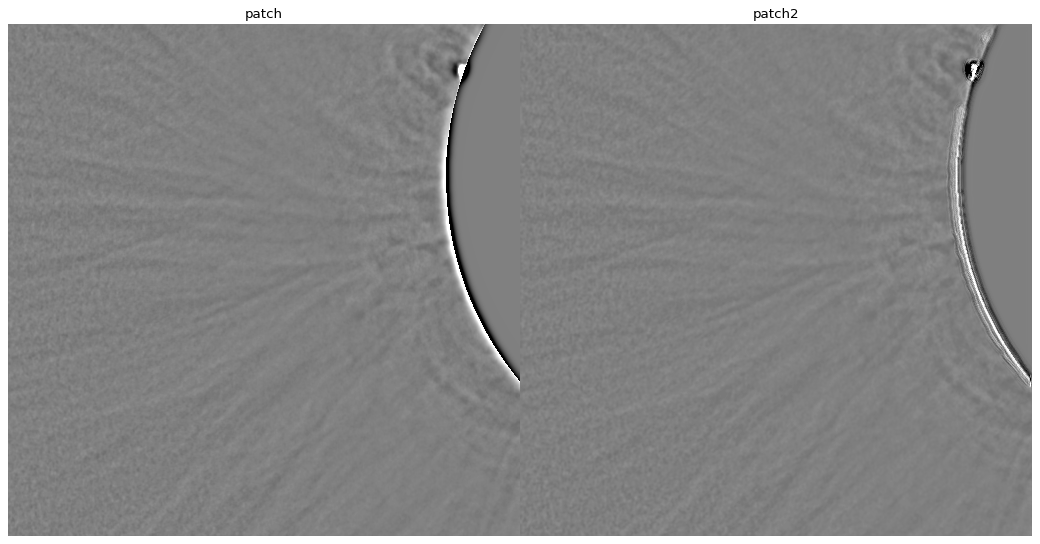

In [13]:
print(diff.shape)
i0 = 1800
j0 = 2100
patch = diff[i0:i0+512, j0:j0+512]
model.eval()
patch2 = model(patch.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)
print(patch.shape)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(2 * 512 / 80, 512 / 80), dpi=80)
ax0.imshow(patch.detach().cpu().numpy(), cmap="gray", vmin=-0.1, vmax=0.1)
ax0.axis("off")
ax0.set_title("patch")
ax1.imshow(patch2.detach().cpu().numpy(), cmap="gray", vmin=-0.1, vmax=0.1)
ax1.axis("off")
ax1.set_title("patch2")
plt.subplots_adjust(0, 0, 1, 1, wspace=0)
plt.show()